In [1]:
# System
import sys

sys.path.append("..")

In [2]:
# Setup
from importlib import import_module
from pathlib import Path

import numpy as np

from src.utils import (
    show_record_dataset,
    show_record_dataset_correlation,
    show_record_feature,
)

In [3]:
# Parameters
dataset_name = "real1"  # *
n_samples = 200000
seed = 42

# Plotting *
bins = [
    np.linspace(0, 200, 101),
    np.linspace(0, 0.5, 101),
    np.linspace(0, 0.2, 101),
    np.linspace(0, 5, 101),
    np.linspace(0, 5, 101),
    np.linspace(0, 1, 101),
]
feature_names = ["mass", "c2_beta1", "c2_beta2", "d2_beta1", "d2_beta2", "tau21_beta1"]
feature_names_latex = [
    r"$M_{\text{jet}}$",
    r"$C_2^{\beta=1}$",
    r"$C_2^{\beta=2}$",
    r"$D_2^{\beta=1}$",
    r"$D_2^{\beta=2}$",
    r"$\tau_{21}^{\beta=1}$",
]

# Paths
PNG_DIR_PATH = Path("../figures/pngs")
PDF_DIR_PATH = Path("../figures/pdfs")

In [4]:
# Dataset
module = import_module(f"src.datasets.{dataset_name}")
load_data = getattr(module, "load_data")
(x_train, y_train), _ = load_data(n_samples, seed)

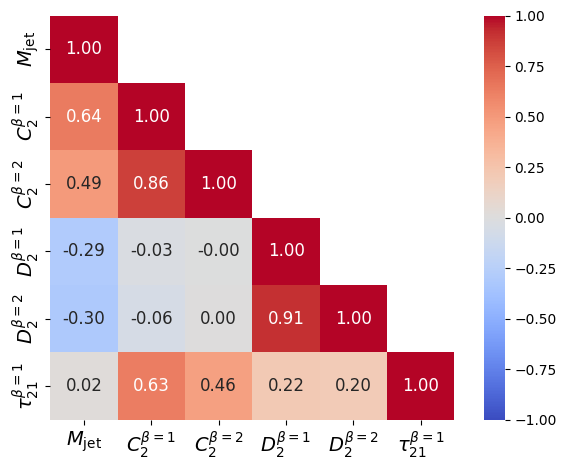

In [5]:
# Figure: correlation
show_record_dataset_correlation(x_train, feature_names_latex)

show_record_dataset_correlation(
    x_train,
    feature_names_latex,
    to_file=PNG_DIR_PATH / f"dataset-{dataset_name}_correlation.png",
)
show_record_dataset_correlation(
    x_train,
    feature_names_latex,
    to_file=PDF_DIR_PATH / f"dataset-{dataset_name}_correlation.pdf",
)

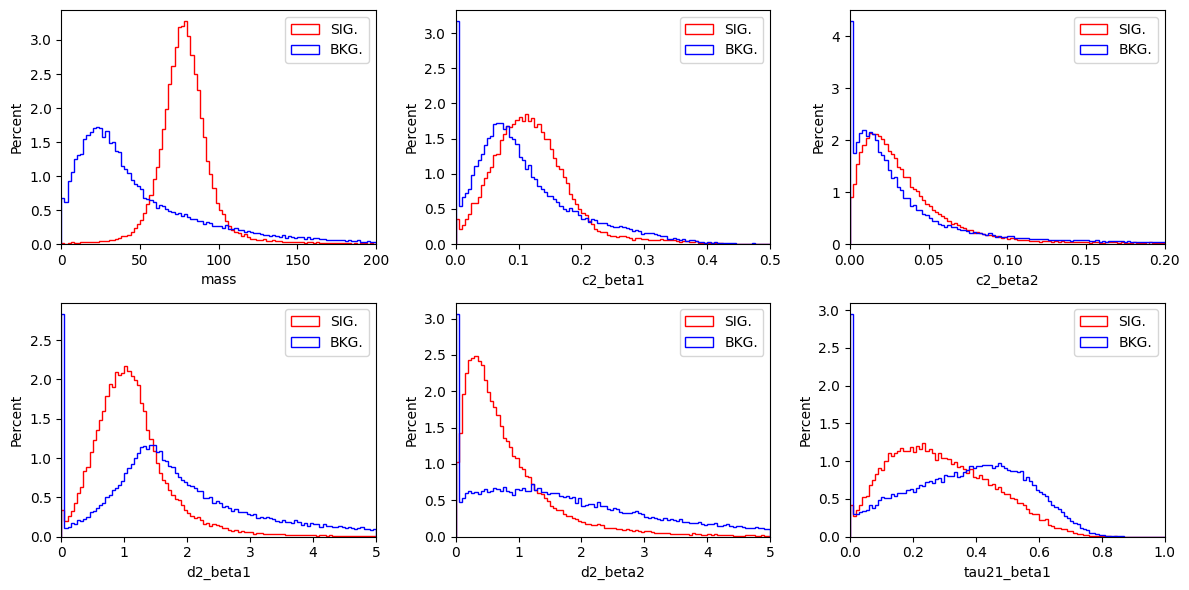

In [6]:
# Figure: distributions
show_record_dataset(x_train, y_train, bins, feature_names)

for i in range(x_train.shape[1]):
    show_record_feature(
        x_train,
        y_train,
        bins[i],
        feature_index=i,
        feature_name=feature_names_latex[i],
        to_file=PNG_DIR_PATH / f"dataset-{dataset_name}_{feature_names[i]}.png",
    )
    show_record_feature(
        x_train,
        y_train,
        bins[i],
        feature_index=i,
        feature_name=feature_names_latex[i],
        to_file=PDF_DIR_PATH / f"dataset-{dataset_name}_{feature_names[i]}.pdf",
    )